In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data import SECTORS

px = pd.read_parquet("../data/raw/prices.parquet").dropna(how="all").ffill()
macro = pd.read_parquet("../data/raw/macro.parquet")

tickers = list(SECTORS)
print(px.tail(3))
print(macro.notna().idxmax())   # first valid date per macro series

Matplotlib is building the font cache; this may take a moment.
/Users/chaitanya/Desktop/sector-thesis/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Ticker             SPY        XLB         XLC        XLE        XLF  \
Date                                                                  
2026-09-30  762.630005  48.700001  110.970001  61.500000  53.400002   
2026-10-01  763.989990  48.540001  109.940002  62.700001  53.459999   
2026-10-02  769.640015  48.860001  110.320000  62.820000  53.490002   

Ticker             XLI         XLK        XLP       XLRE        XLU  \
Date                                                                  
2026-09-30  166.979996  195.750000  80.599998  40.910000  39.439999   
2026-10-01  168.639999  197.809998  80.330002  40.680000  39.680000   
2026-10-02  169.949997  199.809998  80.529999  40.810001  39.830002   

Ticker             XLV         XLY  
Date                                
2026-09-30  168.419998  108.839996  
2026-10-01  166.199997  108.809998  
2026-10-02  166.179993  110.040001  
yield_curve   2015-01-02
hy_spread     2023-10-03
ten_year      2015-01-02
usd_index     2015-01-02
vix

In [2]:
rel = px[tickers].div(px["SPY"], axis=0)

def ret(series_df, start_offset, end_offset=1):
    # return from iloc[-start_offset] to iloc[-end_offset]
    return series_df.iloc[-end_offset] / series_df.iloc[-start_offset] - 1

mom = pd.DataFrame({
    "mom_3m":  ret(rel, 64),
    "mom_6m":  ret(rel, 127),
    "mom_12_1": ret(rel, 253, 22),   # 12 months, skipping the latest month
})
mom

,mom_3m,mom_6m,mom_12_1
Ticker,,,
XLK,0.061107,0.248658,0.122241
XLF,-0.068953,-0.077925,-0.052872
XLE,0.158161,-0.089220,0.291023
XLV,0.002922,-0.032386,0.057867
XLY,-0.090036,-0.133730,-0.169654
XLP,-0.061475,-0.154943,-0.033329
XLI,-0.105790,-0.115641,-0.018159
XLB,-0.080507,-0.171370,0.048547
XLU,-0.137556,-0.261230,-0.142590


In [3]:
daily = px[tickers].pct_change().dropna()
last12 = daily.iloc[-252:]

vol = last12.std() * np.sqrt(252)

wealth = (1 + last12).cumprod()
max_dd = (wealth / wealth.cummax() - 1).min()   # negative number

risk = pd.DataFrame({"vol": vol, "max_dd": max_dd})
risk

,vol,max_dd
Ticker,,
XLK,0.264839,-0.159227
XLF,0.147659,-0.147947
XLE,0.218873,-0.149763
XLV,0.157211,-0.104699
XLY,0.194646,-0.149757
XLP,0.144654,-0.096878
XLI,0.173014,-0.122135
XLB,0.178660,-0.123834
XLU,0.152327,-0.160501


In [4]:
factors = ["yield_curve", "hy_spread", "usd_index", "ten_year"]

wk_macro = macro[factors].resample("W-FRI").last().ffill().diff()
wk_px = px.resample("W-FRI").last().pct_change()
excess = wk_px[tickers].sub(wk_px["SPY"], axis=0)

data = pd.concat([excess, wk_macro], axis=1).dropna().iloc[-156:]
X = (data[factors] - data[factors].mean()) / data[factors].std()
X1 = np.column_stack([np.ones(len(X)), X.values])

betas = pd.DataFrame(
    {t: np.linalg.lstsq(X1, data[t].values, rcond=None)[0][1:] for t in tickers},
    index=factors,
).T

# Recent macro move: 13-week cumulative change, standardized with the same stats
recent = wk_macro[factors].iloc[-13:].sum()
recent_z = (recent - data[factors].mean() * 13) / (data[factors].std() * np.sqrt(13))

macro_tilt = betas.mul(recent_z, axis=1).sum(axis=1).rename("macro_tilt")
betas.round(4)

,yield_curve,hy_spread,usd_index,ten_year
XLK,-0.0023,-0.0049,-0.0019,0.0015
XLF,0.0016,-0.0020,0.0031,-0.0007
XLE,-0.0003,0.0038,0.0050,0.0081
XLV,0.0001,0.0082,0.0003,-0.0021
XLY,0.0019,-0.0028,0.0003,-0.0042
XLP,0.0009,0.0111,0.0001,-0.0018
XLI,0.0004,-0.0004,0.0001,-0.0005
XLB,0.0003,0.0028,-0.0034,-0.0026
XLU,-0.0014,0.0115,0.0003,-0.0046
XLRE,0.0014,0.0037,0.0003,-0.0103


In [5]:
def z(s):
    return (s - s.mean()) / s.std()

scores = pd.DataFrame(index=tickers)
scores["momentum"] = pd.concat([z(mom[c]) for c in mom], axis=1).mean(axis=1)
scores["low_risk"] = (z(-risk["vol"]) + z(risk["max_dd"])) / 2   # lower vol, shallower drawdown = better
scores["macro_fit"] = z(macro_tilt)

scores["composite"] = scores[["momentum", "low_risk", "macro_fit"]].mean(axis=1)
scores["sector"] = pd.Series(SECTORS)
scores = scores.sort_values("composite", ascending=False)
scores.round(2)

,momentum,low_risk,macro_fit,composite,sector
XLE,1.53,-0.98,2.04,0.86,Energy
XLV,0.51,0.81,0.53,0.62,Health Care
XLP,-0.28,1.15,0.95,0.61,Consumer Staples
XLC,-0.43,0.51,0.10,0.06,Communication Services
XLI,-0.31,0.23,-0.18,-0.09,Industrials
XLB,-0.19,0.11,-0.20,-0.09,Materials
XLK,1.61,-1.79,-0.36,-0.18,Technology
XLF,-0.16,0.00,-0.42,-0.19,Financials
XLU,-1.11,-0.33,0.38,-0.35,Utilities
XLRE,-0.51,0.95,-1.65,-0.40,Real Estate


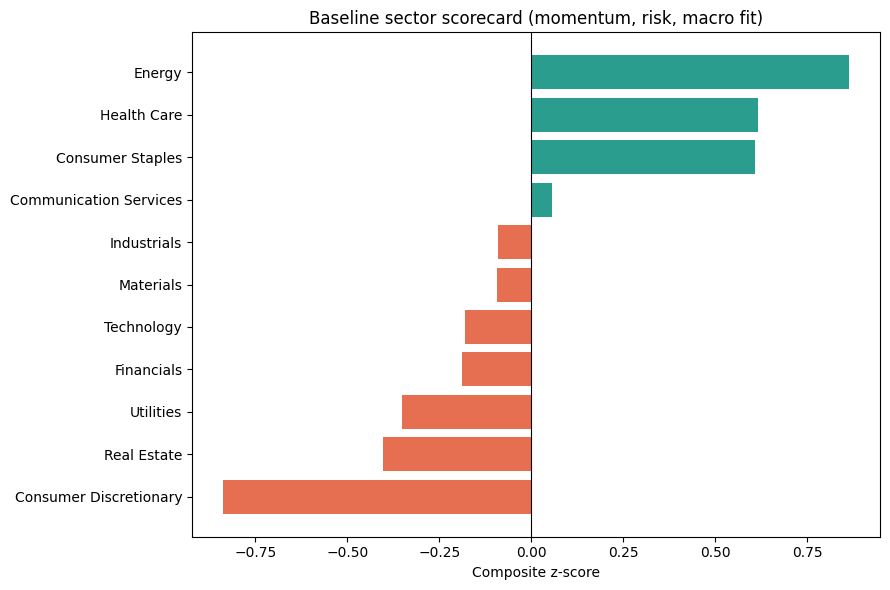

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
s = scores.sort_values("composite")
colors = ["#2a9d8f" if v > 0 else "#e76f51" for v in s["composite"]]
ax.barh(s["sector"], s["composite"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Baseline sector scorecard (momentum, risk, macro fit)")
ax.set_xlabel("Composite z-score")
plt.tight_layout()
plt.savefig("../figures/scorecard_baseline.png", dpi=200)
plt.show()

scores.to_csv("../data/processed/scorecard_baseline.csv")